In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm

/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value

In [2]:
client = scaleout.make_dask_client("tls://localhost:8786")
client

Connection method: Direct,
Dashboard: /user/maria.jose@cern.ch/proxy/8787/status,
Comm: tls://192.168.161.189:8786,Workers: 0
Dashboard: /user/maria.jose@cern.ch/proxy/8787/status,Total threads: 0
Started: 1 hour ago,Total memory: 0 B


In [2]:

signal = [
    '2Mu2E_500GeV_5p0GeV_80p0mm',
]


In [3]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.DaskExecutor(client=client),
    # schema=NanoAODSchema,
    schema = llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)
channelname="base_ljObjCut_ljIso"
hist_collections = "displacement_base"
channels = [ 
           channelname,
   
           
           ]
p = sidm_processor.SidmProcessor(
    channels,
    [
  hist_collections
    ],
)

In [4]:
fileset = utilities.make_fileset(signal, "llpNanoAOD_v2", max_files=-1, location_cfg="signal_2mu2e_v10.yaml", replace_xcache=True)

                            

output_signal = runner.run(fileset, treename="Events", processor_instance=p)
# coffea.util.save(output_signal, "output_signal"+ channelname+ ".coffea"  )

Output()

Output()

/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/coffea/
nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => 
Electron
  warnings.warn(

/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/coffea/
nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => 
Photon
  warnings.warn(

/uscms/home/scampbel/nobackup/CMSSW_14_1_0_pre4/src/SIDM_fresh/.python_userbase/lib/python3.9/site-packages/awkward
/_nplikes/array_module.py:292: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

...

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

2Mu2E_500GeV_5p0GeV_80p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


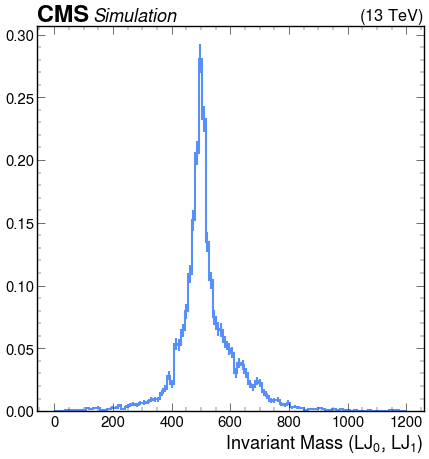

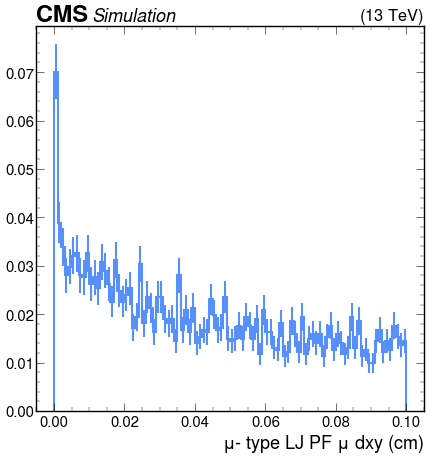

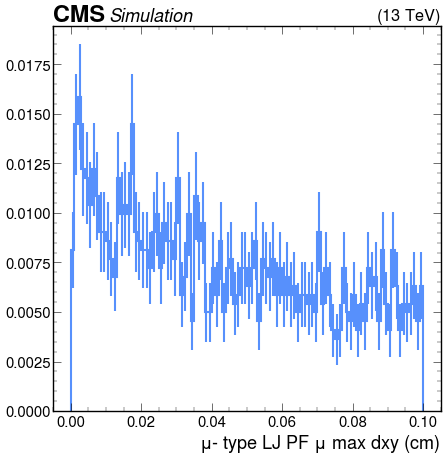

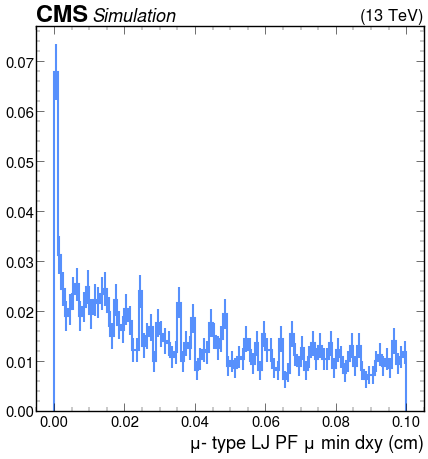

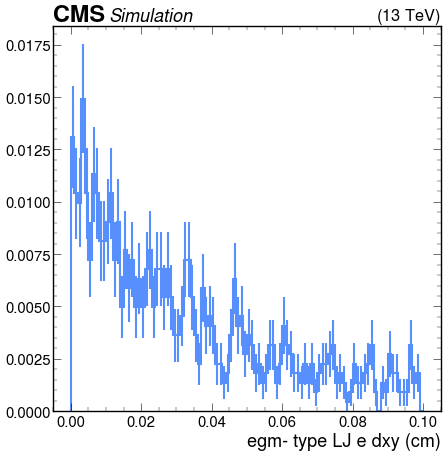

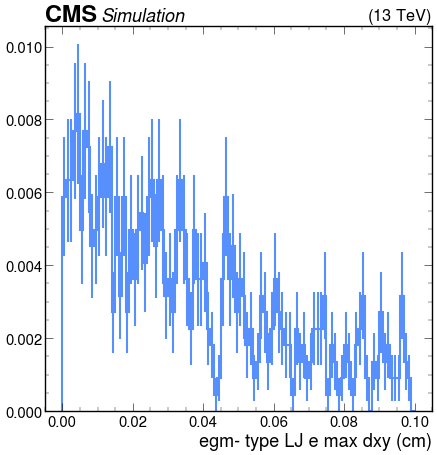

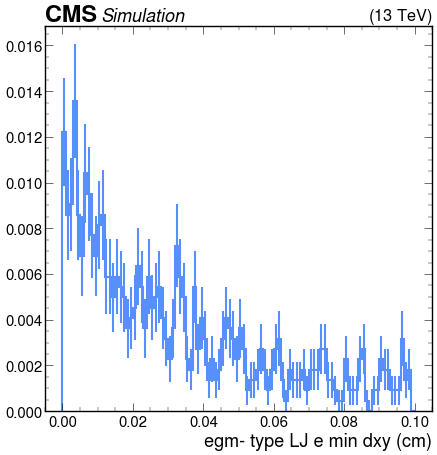

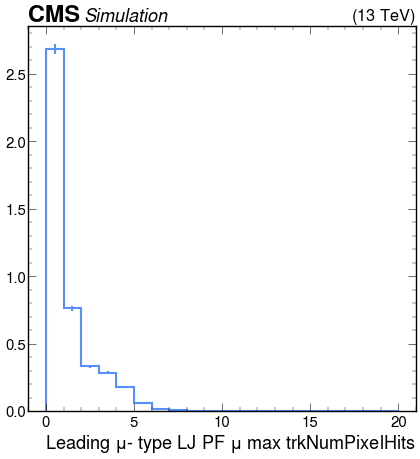

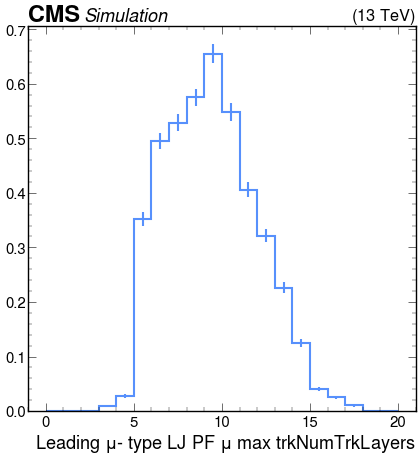

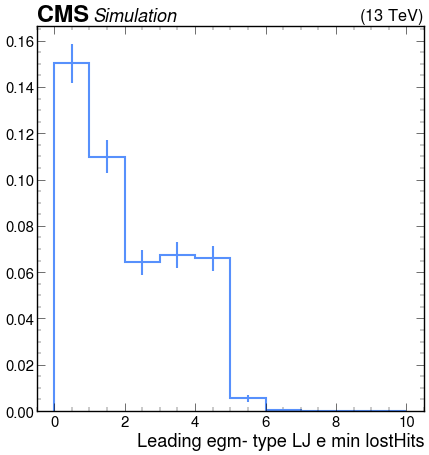

In [5]:

histogram_list  = [ 
 "mulj_egmlj_invmass",
"mu_lj_pfMuon_dxy_XLowRange",
"mu_lj_pfMuon_max_dxy_XLowRange",
"mu_lj_pfMuon_min_dxy_XLowRange",
"egm_lj_electron_dxy_XXXLowRange",
"egm_lj_electron_max_dxy_XXXLowRange",
 "egm_lj_electron_min_dxy_XXXLowRange",
"leading_mu_lj_pfMu_max_trkNumPixelHits",
# "leading_mu_lj_muon_max_trkNumTrkLayers",
"leading_mu_lj_pfMu_max_trkNumTrkLayers",
# "leading_pf_mu_lj_pfMu_max_trkNumTrkLayers",
# "leading_pf_dsa_mu_lj_pfMu_max_trkNumTrkLayers",
"leading_egm_lj_electron_min_lostHits",
]



for i, histogram_name in enumerate(histogram_list):
    histogram = output_signal["out"][signal[0]]["hists"][histogram_name][channelname, :]
    utilities.plot(histogram, flow ="none", yerr=True, density=False,  linewidth=3)
    # plt.yscale("log")
    plt.show()
    plt.close()